<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Bar Charts**


Estimated time needed: **30** minutes


In this lab, you will focus on visualizing data.

The dataset will be provided to you in the form of an RDBMS.

You will use SQL queries to extract the necessary data.


## Objectives


In this lab you will perform the following:


-   Visualize the distribution of data

-   Visualize the relationship between two features

-   Visualize the composition of data

-   Visualize comparison of data


## Setup: Working with the Database
**Install the needed libraries**


In [1]:
!pip install pandas

In [2]:
!pip install matplotlib

**Download and connect to the database file containing survey data.**


To start, download and load the dataset into a `pandas` DataFrame.



In [3]:
# Step 1: Download the dataset
!wget -O survey-data.csv https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv

# Step 2: Import necessary libraries and load the dataset
import pandas as pd
import matplotlib.pyplot as plt

# Load the data
df = pd.read_csv("survey-data.csv")

# Display the first few rows to understand the structure of the data
df.head()


--2026-05-21 02:51:22--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 159525875 (152M) [text/csv]
Saving to: ‘survey-data.csv’

survey-data.csv     100%[===================>] 152.13M  5.83MB/s    in 24s     

2026-05-21 02:51:47 (6.25 MB/s) - ‘survey-data.csv’ saved [159525875/159525875]


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Task 1: Visualizing Data Distributions


##### 1. Histogram of `ConvertedCompYearly`


Visualize the distribution of yearly compensation (`ConvertedCompYearly`) using a histogram.



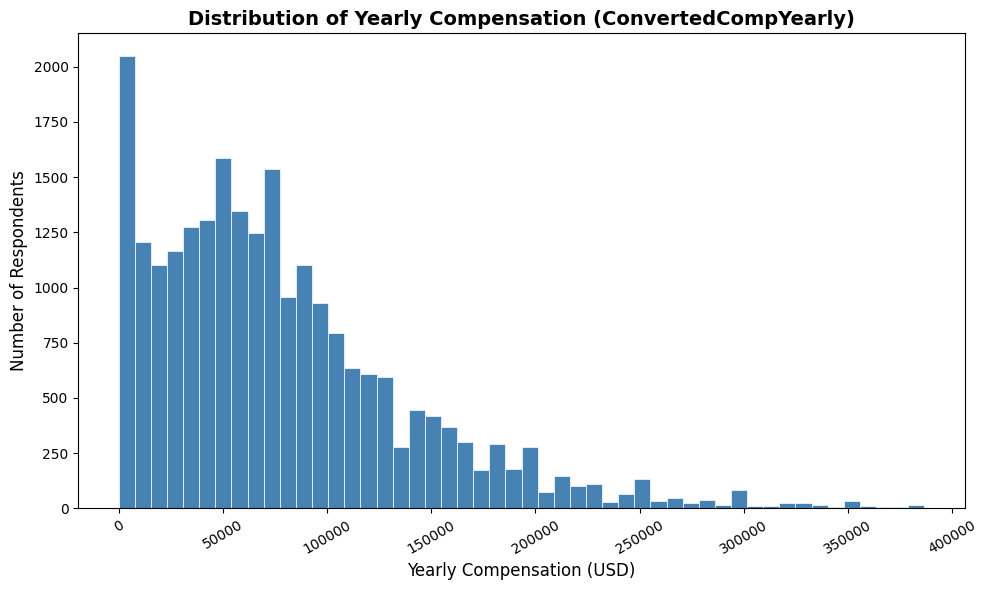

Total respondents with comp data: 23,435
Median compensation: $65,000
Mean compensation:   $86,155

In [4]:
## Write your code here
# Task 1.1: Histogram of ConvertedCompYearly
comp_data = df['ConvertedCompYearly'].dropna()

# Cap at 99th percentile to reduce extreme outlier distortion
cap = comp_data.quantile(0.99)
comp_filtered = comp_data[comp_data <= cap]

plt.figure(figsize=(10, 6))
plt.hist(comp_filtered, bins=50, color='steelblue', edgecolor='white', linewidth=0.5)
plt.title('Distribution of Yearly Compensation (ConvertedCompYearly)', fontsize=14, fontweight='bold')
plt.xlabel('Yearly Compensation (USD)', fontsize=12)
plt.ylabel('Number of Respondents', fontsize=12)
plt.ticklabel_format(style='plain', axis='x')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()
print(f"Total respondents with comp data: {len(comp_data):,}")
print(f"Median compensation: ${comp_data.median():,.0f}")
print(f"Mean compensation:   ${comp_data.mean():,.0f}")

##### 2. Box Plot of `Age`


Since `Age` is categorical in the dataset, convert it to numerical values for a box plot.



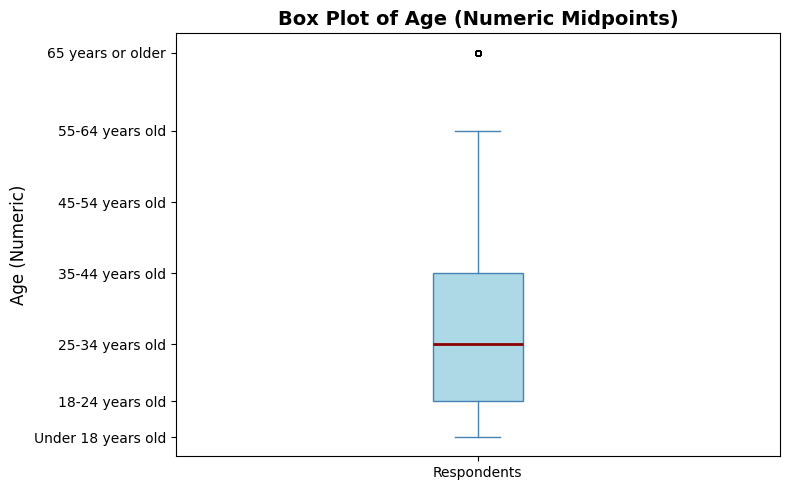

Age distribution summary:
count    65115.0
mean        32.6
std         11.1
min         16.0
25%         21.0
50%         29.0
75%         39.0
max         70.0
Name: Age_numeric, dtype: float64

In [5]:
## Write your code here
# Task 1.2: Box Plot of Age (converted to numeric)

# Map age groups to midpoint numeric values
age_map = {
    'Under 18 years old': 16,
    '18-24 years old': 21,
    '25-34 years old': 29,
    '35-44 years old': 39,
    '45-54 years old': 49,
    '55-64 years old': 59,
    '65 years or older': 70
}

df['Age_numeric'] = df['Age'].map(age_map)

age_numeric = df['Age_numeric'].dropna()

plt.figure(figsize=(8, 5))
plt.boxplot(age_numeric, vert=True, patch_artist=True,
            boxprops=dict(facecolor='lightblue', color='steelblue'),
            medianprops=dict(color='darkred', linewidth=2),
            whiskerprops=dict(color='steelblue'),
            capprops=dict(color='steelblue'),
            flierprops=dict(marker='o', color='gray', alpha=0.3, markersize=4))

plt.title('Box Plot of Age (Numeric Midpoints)', fontsize=14, fontweight='bold')
plt.ylabel('Age (Numeric)', fontsize=12)
plt.xticks([1], ['Respondents'])
plt.yticks(sorted(age_map.values()), [k for k, v in sorted(age_map.items(), key=lambda x: x[1])])
plt.tight_layout()
plt.show()
print("Age distribution summary:")
print(age_numeric.describe().round(1))

### Task 2: Visualizing Relationships in Data


##### 1. Scatter Plot of `Age_numeric` and `ConvertedCompYearly`


Explore the relationship between age and compensation.



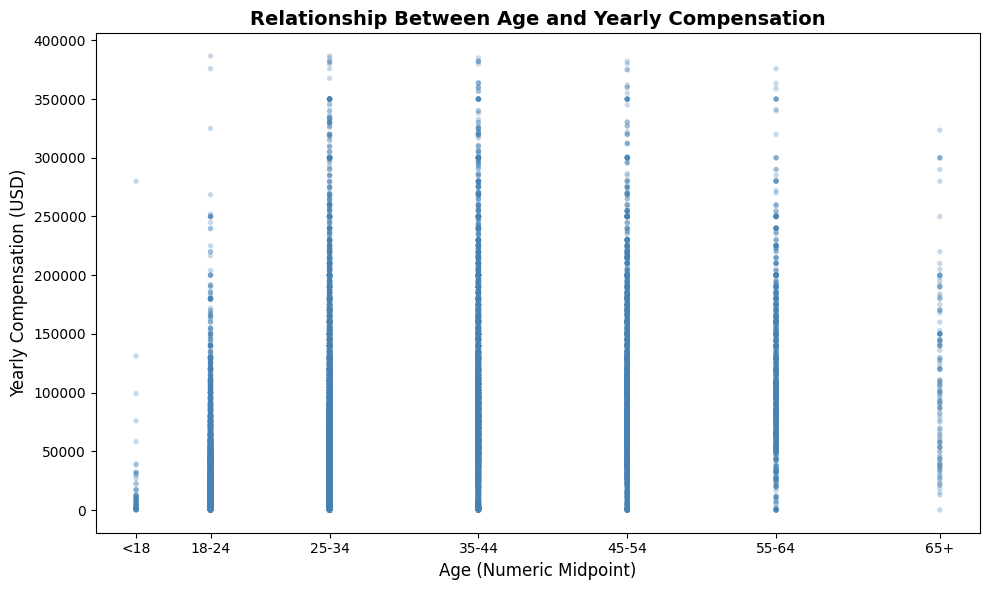

In [6]:
## Write your code here
# Task 2.1: Scatter Plot of Age_numeric vs ConvertedCompYearly
scatter_df = df[['Age_numeric', 'ConvertedCompYearly']].dropna()
# Cap compensation at 99th percentile for readability
cap = scatter_df['ConvertedCompYearly'].quantile(0.99)
scatter_df = scatter_df[scatter_df['ConvertedCompYearly'] <= cap]

plt.figure(figsize=(10, 6))
plt.scatter(scatter_df['Age_numeric'], scatter_df['ConvertedCompYearly'],
            alpha=0.3, color='steelblue', edgecolors='none', s=15)
plt.title('Relationship Between Age and Yearly Compensation', fontsize=14, fontweight='bold')
plt.xlabel('Age (Numeric Midpoint)', fontsize=12)
plt.ylabel('Yearly Compensation (USD)', fontsize=12)
plt.xticks([16, 21, 29, 39, 49, 59, 70],
           ['<18', '18-24', '25-34', '35-44', '45-54', '55-64', '65+'])
plt.tight_layout()
plt.show()

##### 2. Bubble Plot of `ConvertedCompYearly` and `JobSatPoints_6` with `Age_numeric` as Bubble Size


Explore how compensation and job satisfaction are related, with age as the bubble size.


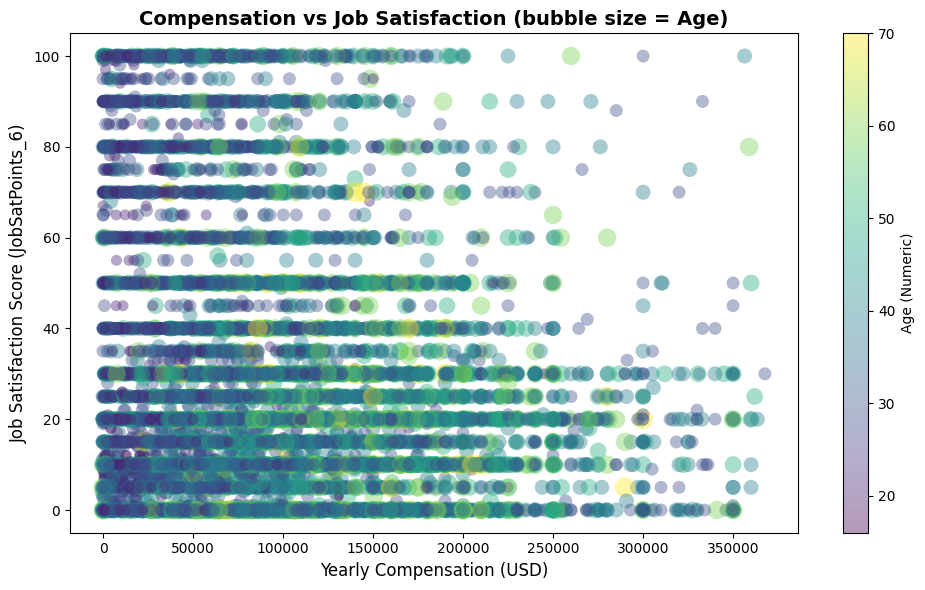

In [7]:
## Write your code here
# Task 2.2: Bubble Plot of ConvertedCompYearly vs JobSatPoints_6 with Age_numeric as bubble size
bubble_df = df[['ConvertedCompYearly', 'JobSatPoints_6', 'Age_numeric']].dropna()
cap = bubble_df['ConvertedCompYearly'].quantile(0.99)
bubble_df = bubble_df[bubble_df['ConvertedCompYearly'] <= cap]

plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    bubble_df['ConvertedCompYearly'],
    bubble_df['JobSatPoints_6'],
    s=bubble_df['Age_numeric'] * 3,       # bubble size scaled from Age_numeric
    c=bubble_df['Age_numeric'],            # color also mapped to age
    cmap='viridis', alpha=0.4, edgecolors='none'
)
cbar = plt.colorbar(scatter)
cbar.set_label('Age (Numeric)', fontsize=10)
plt.title('Compensation vs Job Satisfaction (bubble size = Age)', fontsize=14, fontweight='bold')
plt.xlabel('Yearly Compensation (USD)', fontsize=12)
plt.ylabel('Job Satisfaction Score (JobSatPoints_6)', fontsize=12)
plt.tight_layout()
plt.show()

### Task 3: Visualizing Composition of Data with Bar Charts


##### 1. Horizontal Bar Chart of `MainBranch` Distribution


Visualize the distribution of respondents’ primary roles to understand their professional focus.



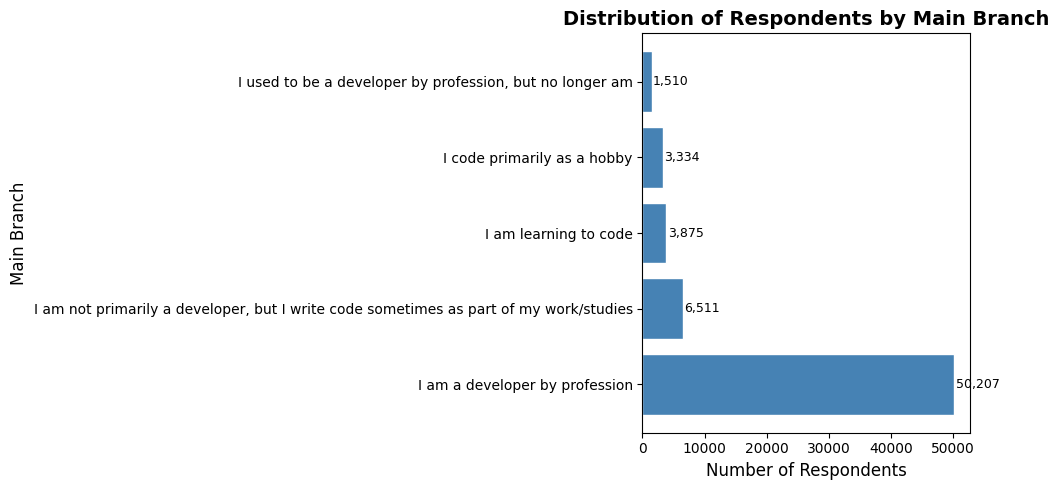

In [8]:
## Write your code here
# Task 3.1: Horizontal Bar Chart of MainBranch Distribution
branch_counts = df['MainBranch'].value_counts()

plt.figure(figsize=(10, 5))
bars = plt.barh(branch_counts.index, branch_counts.values, color='steelblue', edgecolor='white')
plt.title('Distribution of Respondents by Main Branch', fontsize=14, fontweight='bold')
plt.xlabel('Number of Respondents', fontsize=12)
plt.ylabel('Main Branch', fontsize=12)
# Add value labels on bars
for bar, val in zip(bars, branch_counts.values):
    plt.text(val + 200, bar.get_y() + bar.get_height()/2,
             f'{val:,}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

##### 2. Vertical Bar Chart of Top 5 Programming Languages Respondents Want to Work With


Identify the most desired programming languages based on `LanguageWantToWorkWith`.



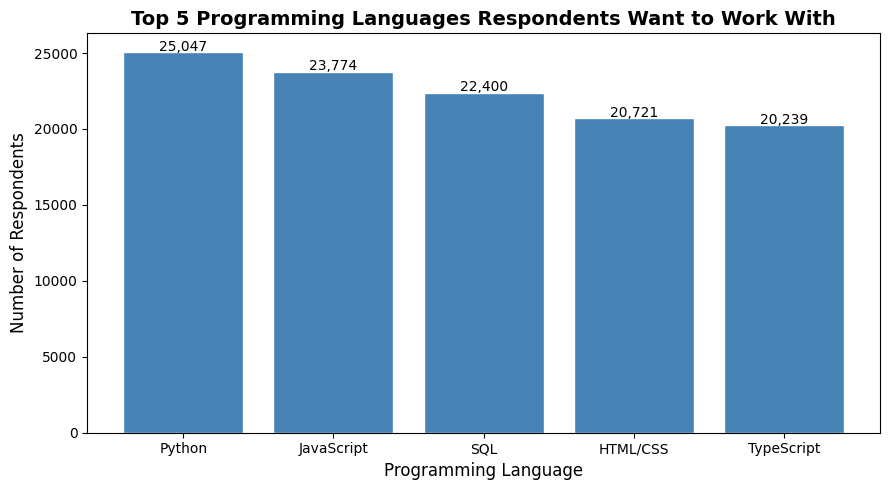

In [9]:
## Write your code here
# Task 3.2: Vertical Bar Chart of Top 5 Programming Languages (LanguageWantToWorkWith)
lang_series = df['LanguageWantToWorkWith'].dropna().str.split(';').explode()
top5_langs = lang_series.value_counts().head(5)

plt.figure(figsize=(9, 5))
bars = plt.bar(top5_langs.index, top5_langs.values, color='steelblue', edgecolor='white')
plt.title('Top 5 Programming Languages Respondents Want to Work With', fontsize=14, fontweight='bold')
plt.xlabel('Programming Language', fontsize=12)
plt.ylabel('Number of Respondents', fontsize=12)
for bar, val in zip(bars, top5_langs.values):
    plt.text(bar.get_x() + bar.get_width()/2, val + 100,
             f'{val:,}', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

##### 3. Stacked Bar Chart of Median `JobSatPoints_6` and `JobSatPoints_7` by Age Group


Compare job satisfaction metrics across different age groups with a stacked bar chart.


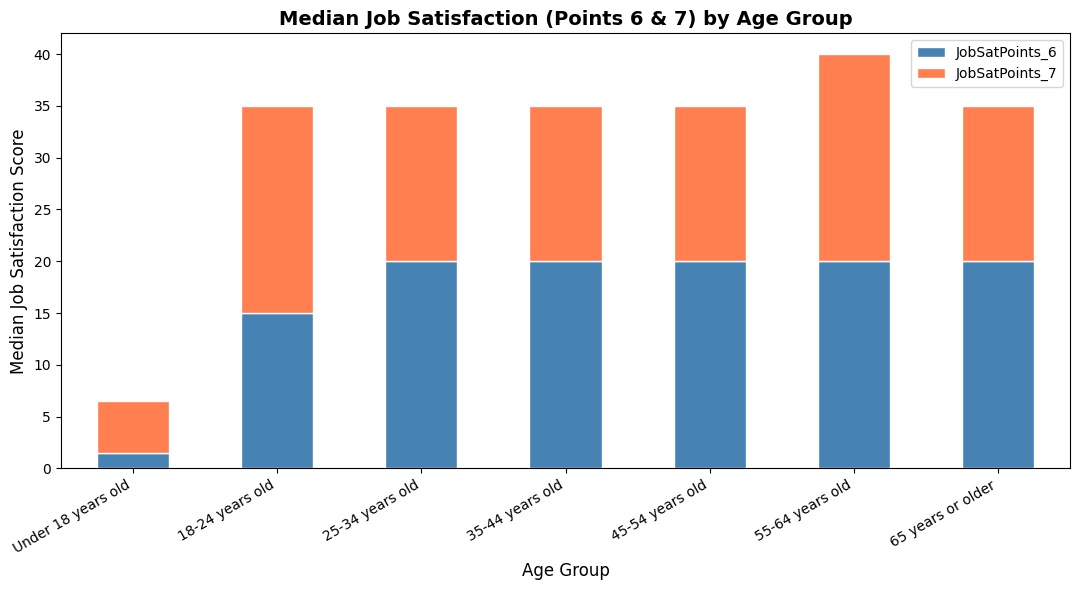

In [10]:
## Write your code here
# Task 3.3: Stacked Bar Chart of Median JobSatPoints_6 and JobSatPoints_7 by Age Group
age_order = ['Under 18 years old', '18-24 years old', '25-34 years old',
             '35-44 years old', '45-54 years old', '55-64 years old', '65 years or older']

stacked_df = df.groupby('Age')[['JobSatPoints_6', 'JobSatPoints_7']].median()
stacked_df = stacked_df.reindex([a for a in age_order if a in stacked_df.index])

ax = stacked_df.plot(kind='bar', stacked=True, figsize=(11, 6),
                     color=['steelblue', 'coral'], edgecolor='white')
plt.title('Median Job Satisfaction (Points 6 & 7) by Age Group', fontsize=14, fontweight='bold')
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Median Job Satisfaction Score', fontsize=12)
plt.xticks(rotation=30, ha='right')
plt.legend(['JobSatPoints_6', 'JobSatPoints_7'], loc='upper right')
plt.tight_layout()
plt.show()

##### 4. Bar Chart of Database Popularity (`DatabaseHaveWorkedWith`)


Identify the most commonly used databases among respondents by visualizing `DatabaseHaveWorkedWith`.



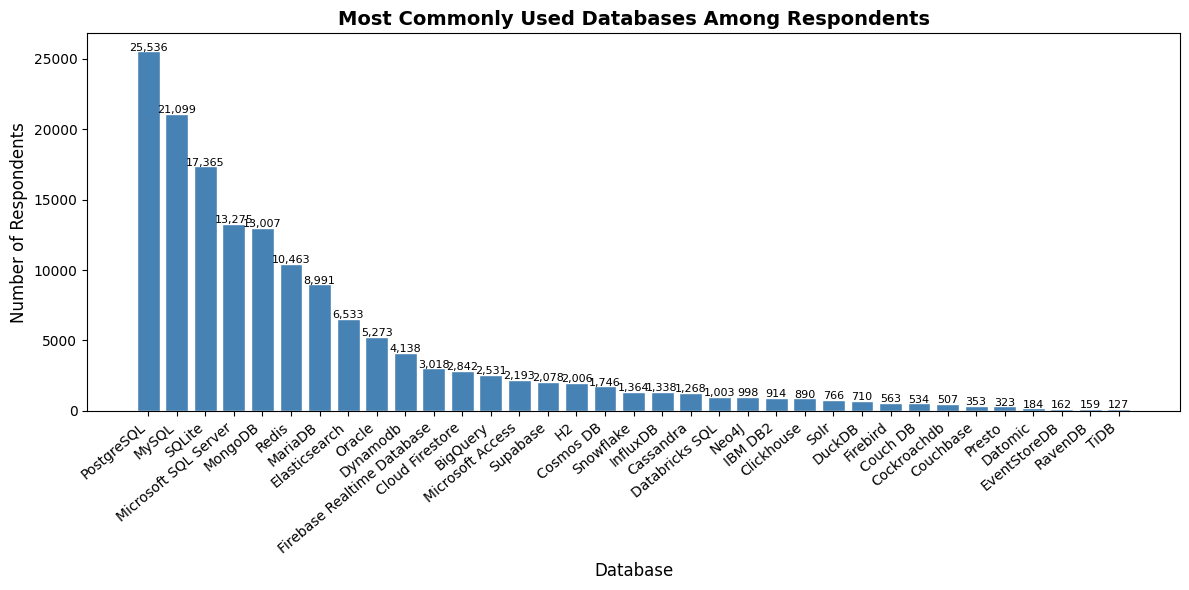

In [11]:
## Write your code here
# Task 3.4: Bar Chart of Database Popularity (DatabaseHaveWorkedWith)
db_series = df['DatabaseHaveWorkedWith'].dropna().str.split(';').explode()
db_counts = db_series.value_counts()

plt.figure(figsize=(12, 6))
bars = plt.bar(db_counts.index, db_counts.values, color='steelblue', edgecolor='white')
plt.title('Most Commonly Used Databases Among Respondents', fontsize=14, fontweight='bold')
plt.xlabel('Database', fontsize=12)
plt.ylabel('Number of Respondents', fontsize=12)
plt.xticks(rotation=40, ha='right')
for bar, val in zip(bars, db_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, val + 50,
             f'{val:,}', ha='center', fontsize=8)
plt.tight_layout()
plt.show()

### Task 4: Visualizing Comparison of Data with Bar Charts


##### 1. Grouped Bar Chart of Median `ConvertedCompYearly` for Different Age Groups


Compare median compensation across multiple age groups with a grouped bar chart.



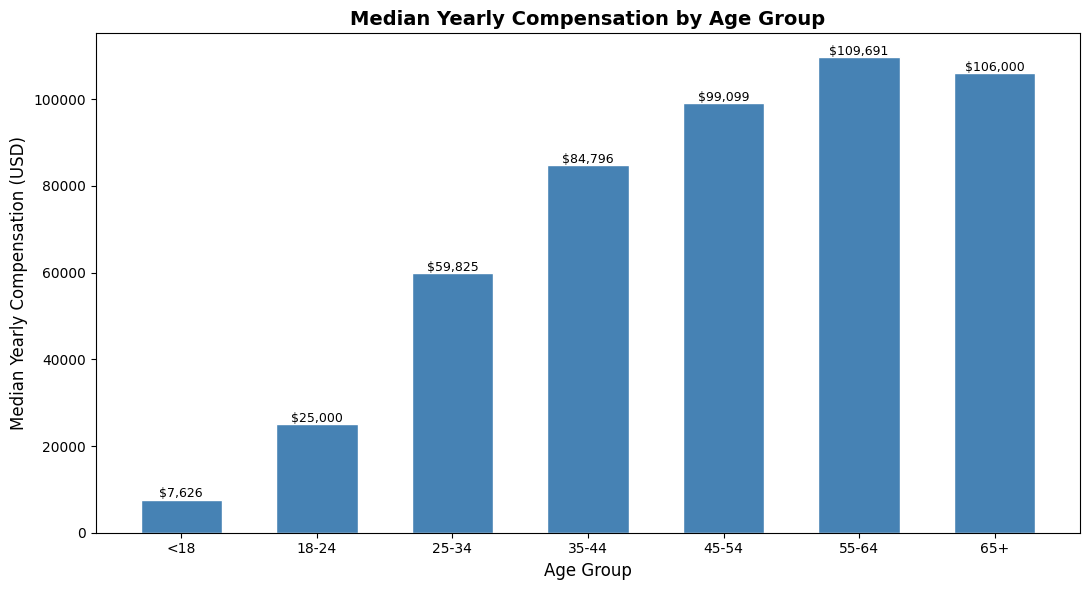

In [12]:
## Write your code here
# Task 4.1: Grouped Bar Chart of Median ConvertedCompYearly by Age Group
age_order = ['Under 18 years old', '18-24 years old', '25-34 years old',
             '35-44 years old', '45-54 years old', '55-64 years old', '65 years or older']

median_comp = df.groupby('Age')['ConvertedCompYearly'].median()
median_comp = median_comp.reindex([a for a in age_order if a in median_comp.index])

short_labels = ['<18', '18-24', '25-34', '35-44', '45-54', '55-64', '65+']

plt.figure(figsize=(11, 6))
bars = plt.bar(range(len(median_comp)), median_comp.values, color='steelblue', edgecolor='white', width=0.6)
plt.title('Median Yearly Compensation by Age Group', fontsize=14, fontweight='bold')
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Median Yearly Compensation (USD)', fontsize=12)
plt.xticks(range(len(median_comp)), short_labels[:len(median_comp)])
for bar, val in zip(bars, median_comp.values):
    plt.text(bar.get_x() + bar.get_width()/2, val + 500,
             f'${val:,.0f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

##### 2. Bar Chart of Respondent Count by Country


Show the distribution of respondents by country to see which regions are most represented.



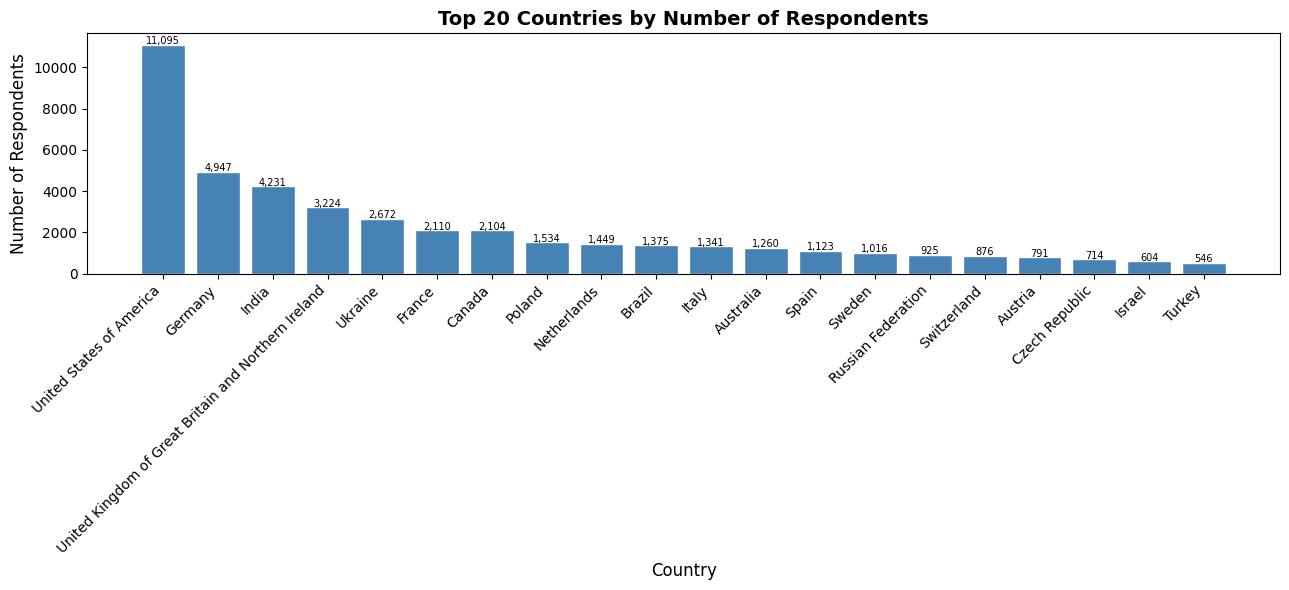

In [13]:
## Write your code here
# Task 4.2: Bar Chart of Respondent Count by Country (Top 20)
country_counts = df['Country'].value_counts().head(20)

plt.figure(figsize=(13, 6))
bars = plt.bar(country_counts.index, country_counts.values, color='steelblue', edgecolor='white')
plt.title('Top 20 Countries by Number of Respondents', fontsize=14, fontweight='bold')
plt.xlabel('Country', fontsize=12)
plt.ylabel('Number of Respondents', fontsize=12)
plt.xticks(rotation=45, ha='right')
for bar, val in zip(bars, country_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, val + 20,
             f'{val:,}', ha='center', fontsize=7)
plt.tight_layout()
plt.show()

### Final Step: Review


This lab demonstrates how to create and interpret different types of bar charts, allowing you to analyze the composition, comparison, and distribution of categorical data in the Stack Overflow dataset, including main professional branches, programming language preferences, and compensation by age group. Bar charts effectively compare counts and median values across various categories.


## Summary


After completing this lab, you will be able to:
- Create a horizontal bar chart to visualize the distribution of respondents' primary roles, helping to understand their professional focus.
- Develop a vertical bar chart to identify the most desired programming languages based on the LanguageWantToWorkWith variable.
- Use a stacked bar chart to compare job satisfaction metrics across different age groups.
- Create a bar chart to visualize the most commonly used databases among respondents using the DatabaseHaveWorkedWith variable.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


Copyright © IBM Corporation. All rights reserved.
